**Seeding for reproducibility**

In [1]:
# Set seeds for reproducibility
import random
random.seed(0)

import numpy as np
np.random.seed(0)

import tensorflow as tf
tf.random.set_seed(0)

**Importing the dependencies**

In [2]:
import os
import json
from zipfile import ZipFile
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

**Data Curation**

Upload the kaggle.json file

In [3]:
!pip install kaggle

In [4]:
kaggle_credentails = json.load(open("kaggle.json"))

In [5]:
# setup Kaggle API key as environment variables
os.environ['KAGGLE_USERNAME'] = kaggle_credentails["username"]
os.environ['KAGGLE_KEY'] = kaggle_credentails["key"]

In [6]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
Resuming from 1156579328 bytes (1032807091 bytes left)...
100% 2.04G/2.04G [00:25<00:00, 40.6MB/s]



In [7]:
!ls

kaggle.json  plantvillage-dataset.zip  sample_data


In [8]:
# Unzip the downloaded dataset
with ZipFile("plantvillage-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall()

In [9]:
print(os.listdir("plantvillage dataset"))


print(len(os.listdir("plantvillage dataset/segmented")))
print(os.listdir("plantvillage dataset/segmented")[:5])

print(len(os.listdir("plantvillage dataset/color")))
print(os.listdir("plantvillage dataset/color")[:5])

print(len(os.listdir("plantvillage dataset/grayscale")))
print(os.listdir("plantvillage dataset/grayscale")[:5])

['color', 'segmented', 'grayscale']
38
['Potato___healthy', 'Strawberry___Leaf_scorch', 'Tomato___Target_Spot', 'Corn_(maize)___Common_rust_', 'Squash___Powdery_mildew']
38
['Potato___healthy', 'Strawberry___Leaf_scorch', 'Tomato___Target_Spot', 'Corn_(maize)___Common_rust_', 'Squash___Powdery_mildew']
38
['Potato___healthy', 'Strawberry___Leaf_scorch', 'Tomato___Target_Spot', 'Corn_(maize)___Common_rust_', 'Squash___Powdery_mildew']


**Number of Classes = 38**

In [10]:
print(len(os.listdir("plantvillage dataset/color/Grape___healthy")))
print(os.listdir("plantvillage dataset/color/Grape___healthy")[:5])

423
['8d435543-bb52-4a00-a84a-02404010cb33___Mt.N.V_HL 9061.JPG', '92fbe3df-dc85-4e06-8109-3a14f5109b29___Mt.N.V_HL 6173.JPG', '0f0596ab-ea6e-472b-a7d5-0a80b1d1ebb2___Mt.N.V_HL 9011.JPG', 'bfd1909d-6235-41a4-a24a-eeea9ffdd0a5___Mt.N.V_HL 9042.JPG', '6f771370-1fb8-440e-a23f-4e0f29dbd65b___Mt.N.V_HL 6150.JPG']


**Data Preprocessing**

In [11]:
# Dataset Path
base_dir = 'plantvillage dataset/color'

(256, 256, 3)


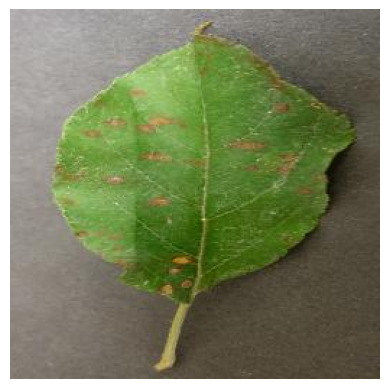

In [12]:
image_path = '/content/plantvillage dataset/color/Apple___Cedar_apple_rust/025b2b9a-0ec4-4132-96ac-7f2832d0db4a___FREC_C.Rust 3655.JPG'

# Read the image
img = mpimg.imread(image_path)

print(img.shape)
# Display the image
plt.imshow(img)
plt.axis('off')  # Turn off axis numbers
plt.show()

In [13]:
image_path = '/content/plantvillage dataset/color/Apple___Cedar_apple_rust/025b2b9a-0ec4-4132-96ac-7f2832d0db4a___FREC_C.Rust 3655.JPG'

# Read the image
img = mpimg.imread(image_path)

print(img)

[[[179 175 176]
  [181 177 178]
  [184 180 181]
  ...
  [115 112 105]
  [108 105  98]
  [101  98  91]]

 [[176 172 173]
  [177 173 174]
  [178 174 175]
  ...
  [113 110 103]
  [111 108 101]
  [109 106  99]]

 [[180 176 177]
  [180 176 177]
  [180 176 177]
  ...
  [108 105  98]
  [111 108 101]
  [114 111 104]]

 ...

 [[137 128 119]
  [131 122 113]
  [125 116 107]
  ...
  [ 74  65  48]
  [ 74  65  48]
  [ 73  64  47]]

 [[136 127 118]
  [132 123 114]
  [128 119 110]
  ...
  [ 77  69  50]
  [ 75  67  48]
  [ 75  67  48]]

 [[133 124 115]
  [133 124 115]
  [132 123 114]
  ...
  [ 81  73  54]
  [ 80  72  53]
  [ 79  71  52]]]


In [14]:
# Image Parameters - Updated for ViT compatibility
img_size = 224  # ViT works well with 224x224 images
patch_size = 16  # Standard patch size for ViT
batch_size = 16  # Reduced batch size for ViT (more memory intensive)

print(f"Image size: {img_size}x{img_size}")
print(f"Patch size: {patch_size}x{patch_size}")
print(f"Number of patches per image: {(img_size//patch_size)**2}")

Image size: 224x224
Patch size: 16x16
Number of patches per image: 196


**Train Test Split**

In [15]:
# Image Data Generators - Updated for ViT
data_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    horizontal_flip=True,  # Data augmentation for ViT
    vertical_flip=False,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

In [16]:
# Train Generator
train_generator = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='training',
    class_mode='categorical'
)

Found 43456 images belonging to 38 classes.


In [17]:
# Validation Generator
validation_generator = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='validation',
    class_mode='categorical'
)

Found 10849 images belonging to 38 classes.


**Hybrid Vision Transformer + CNN Architecture**

In [18]:
# Import additional dependencies for ViT
from tensorflow.keras import layers, models
import tensorflow as tf

# Custom Vision Transformer Components
class PatchEmbedding(layers.Layer):
    def __init__(self, patch_size, embed_dim, **kwargs):
        super(PatchEmbedding, self).__init__(**kwargs)
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.projection = layers.Conv2D(embed_dim, kernel_size=patch_size, strides=patch_size)

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = self.projection(images)  # (batch_size, num_patches, embed_dim)
        patches = tf.reshape(patches, [batch_size, -1, self.embed_dim])
        return patches

    def get_config(self):
        config = super().get_config()
        config.update({
            'patch_size': self.patch_size,
            'embed_dim': self.embed_dim
        })
        return config

class MultiHeadSelfAttention(layers.Layer):
    def __init__(self, embed_dim, num_heads, **kwargs):
        super(MultiHeadSelfAttention, self).__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        assert embed_dim % num_heads == 0

        self.query_dense = layers.Dense(embed_dim)
        self.key_dense = layers.Dense(embed_dim)
        self.value_dense = layers.Dense(embed_dim)
        self.combine_heads = layers.Dense(embed_dim)

    def attention(self, query, key, value):
        score = tf.matmul(query, key, transpose_b=True)
        dim_key = tf.cast(tf.shape(key)[-1], tf.float32)
        scaled_score = score / tf.math.sqrt(dim_key)
        weights = tf.nn.softmax(scaled_score, axis=-1)
        output = tf.matmul(weights, value)
        return output, weights

    def separate_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.head_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        query = self.query_dense(inputs)
        key = self.key_dense(inputs)
        value = self.value_dense(inputs)

        query = self.separate_heads(query, batch_size)
        key = self.separate_heads(key, batch_size)
        value = self.separate_heads(value, batch_size)

        attention, weights = self.attention(query, key, value)
        attention = tf.transpose(attention, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(attention, (batch_size, -1, self.embed_dim))
        output = self.combine_heads(concat_attention)
        return output

    def get_config(self):
        config = super().get_config()
        config.update({
            'embed_dim': self.embed_dim,
            'num_heads': self.num_heads
        })
        return config

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.1, **kwargs):
        super(TransformerBlock, self).__init__(**kwargs)
        self.att = MultiHeadSelfAttention(embed_dim, num_heads)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)

    def call(self, inputs, training=None):
        attn_output = self.att(inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            'embed_dim': self.att.embed_dim,
            'num_heads': self.att.num_heads,
            'ff_dim': self.ffn.layers[0].units,
            'dropout_rate': self.dropout1.rate
        })
        return config

print("Custom ViT components defined successfully!")

Custom ViT components defined successfully!


In [19]:
# Custom CNN components to follow ViT
class CustomCNNBlock(layers.Layer):
    def __init__(self, filters, kernel_size=3, dropout_rate=0.1, **kwargs):
        super(CustomCNNBlock, self).__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size
        self.dropout_rate = dropout_rate

        self.conv1 = layers.Conv2D(filters, kernel_size, padding='same', activation='relu')
        self.bn1 = layers.BatchNormalization()
        self.conv2 = layers.Conv2D(filters, kernel_size, padding='same', activation='relu')
        self.bn2 = layers.BatchNormalization()
        self.pool = layers.MaxPooling2D(pool_size=2)
        self.dropout = layers.Dropout(dropout_rate)

    def call(self, inputs, training=None):
        x = self.conv1(inputs)
        x = self.bn1(x, training=training)
        x = self.conv2(x)
        x = self.bn2(x, training=training)
        x = self.pool(x)
        x = self.dropout(x, training=training)
        return x

    def get_config(self):
        config = super().get_config()
        config.update({
            'filters': self.filters,
            'kernel_size': self.kernel_size,
            'dropout_rate': self.dropout_rate
        })
        return config

print("Custom CNN components defined successfully!")

Custom CNN components defined successfully!


In [20]:
# CNN → ViT Hybrid Model Definition (Recommended Architecture)
def create_cnn_vit_hybrid_model(
    input_shape=(224, 224, 3),
    embed_dim=256,
    num_heads=8,
    ff_dim=512,
    num_transformer_blocks=4,
    num_classes=38,
    dropout_rate=0.1
):
    # Input layer
    inputs = layers.Input(shape=input_shape)

    # CNN Part - Feature Extraction First
    # CNN blocks to extract local features and reduce spatial dimensions
    cnn_block1 = CustomCNNBlock(64, dropout_rate=dropout_rate)(inputs)
    cnn_block2 = CustomCNNBlock(128, dropout_rate=dropout_rate)(cnn_block1)
    cnn_block3 = CustomCNNBlock(256, dropout_rate=dropout_rate)(cnn_block2)

    # Get the shape after CNN processing
    cnn_output_shape = cnn_block3.shape
    reduced_height = cnn_output_shape[1]
    reduced_width = cnn_output_shape[2]
    channels = cnn_output_shape[3]

    # Reshape CNN features for ViT processing
    # Treat each spatial location as a "patch"
    patch_size = 1  # Each pixel location becomes a patch
    num_patches = reduced_height * reduced_width

    # Flatten spatial dimensions and project to embedding dimension
    vit_input = layers.Reshape((num_patches, channels))(cnn_block3)

    # Project to embedding dimension if needed
    if channels != embed_dim:
        vit_input = layers.Dense(embed_dim)(vit_input)

    # Add positional encoding
    positions = tf.range(start=0, limit=num_patches, delta=1)
    position_embedding = layers.Embedding(input_dim=num_patches, output_dim=embed_dim)
    encoded_patches = vit_input + position_embedding(positions)

    # Vision Transformer Part - Global context understanding
    for _ in range(num_transformer_blocks):
        encoded_patches = TransformerBlock(embed_dim, num_heads, ff_dim, dropout_rate)(encoded_patches)

    # Global average pooling over sequence dimension
    vit_features = layers.GlobalAveragePooling1D()(encoded_patches)

    # Final classification
    dense1 = layers.Dense(512, activation='relu')(vit_features)
    dropout = layers.Dropout(dropout_rate)(dense1)
    dense2 = layers.Dense(256, activation='relu')(dropout)
    dropout2 = layers.Dropout(dropout_rate)(dense2)
    outputs = layers.Dense(num_classes, activation='softmax')(dropout2)

    # Create model
    model = models.Model(inputs=inputs, outputs=outputs)
    return model

# Create the CNN → ViT hybrid model
model = create_cnn_vit_hybrid_model()

# Model summary
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_cnn_block                │ (None, 112, 112, 64)   │        39,232 │
│ (CustomCNNBlock)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_cnn_block_1              │ (None, 56, 56, 128)    │       222,464 │
│ (CustomCNNBlock)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_cnn_block_2              │ (None, 28, 28, 256)    │       887,296 │
│ (CustomCNNBlock)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 784, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 784, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 784, 256)       │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 784, 256)       │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 784, 256)       │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 784, 256)       │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,530,086 (13.47 MB)

 Trainable params: 3,528,294 (13.46 MB)

 Non-trainable params: 1,792 (7.00 KB)

# Compile the Hybrid Model with optimized settings
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callbacks for better training
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Compile with learning rate scheduling
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'top_k_categorical_accuracy']
)

print("Hybrid ViT + CNN model compiled successfully with optimizations!")

In [21]:
# Training Hybrid Model with callbacks
print("Training Hybrid ViT + CNN Model with optimizations...")

# First create the model
model = create_cnn_vit_hybrid_model()

# Model summary
print("Model Architecture:")
model.summary()

# First compile model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'top_k_categorical_accuracy']
)

print("Model compiled successfully!")

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)


history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=5,  # Increased epochs with early stopping
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Training Hybrid ViT + CNN Model with optimizations...
Model Architecture:


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_cnn_block_3              │ (None, 112, 112, 64)   │        39,232 │
│ (CustomCNNBlock)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_cnn_block_4              │ (None, 56, 56, 128)    │       222,464 │
│ (CustomCNNBlock)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_cnn_block_5              │ (None, 28, 28, 256)    │       887,296 │
│ (CustomCNNBlock)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 784, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_1 (Add)                     │ (None, 784, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_4             │ (None, 784, 256)       │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_5             │ (None, 784, 256)       │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_6             │ (None, 784, 256)       │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_7             │ (None, 784, 256)       │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,530,086 (13.47 MB)

 Trainable params: 3,528,294 (13.46 MB)

 Non-trainable params: 1,792 (7.00 KB)

Model compiled successfully!
Epoch 1/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 1224s 431ms/step - accuracy: 0.7617 - loss: 0.8188 - top_k_categorical_accuracy: 0.9418 - val_accuracy: 0.9062 - val_loss: 0.3082 - val_top_k_categorical_accuracy: 0.9956 - learning_rate: 1.0000e-04
Epoch 2/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 1151s 424ms/step - accuracy: 0.9099 - loss: 0.2855 - top_k_categorical_accuracy: 0.9949 - val_accuracy: 0.9123 - val_loss: 0.2914 - val_top_k_categorical_accuracy: 0.9947 - learning_rate: 1.0000e-04
Epoch 3/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 1148s 423ms/step - accuracy: 0.9390 - loss: 0.1941 - top_k_categorical_accuracy: 0.9978 - val_accuracy: 0.9606 - val_loss: 0.1221 - val_top_k_categorical_accuracy: 0.9989 - learning_rate: 1.0000e-04
Epoch 4/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 1148s 423ms/step - accuracy: 0.9496 - loss: 0.1589 - top_k_categorical_accuracy: 0.9983 - val_accuracy: 0.9552 - val_loss: 0.1465 - val_top_k_categorical_accuracy: 0.9990 - learning_rate: 1.0000e-04
Epoch 5/5
2

**Model Evaluation**

In [24]:
# Model Evaluation with additional metrics
print("Evaluating model...")
val_loss, val_accuracy, val_top_k_accuracy = model.evaluate(
    validation_generator,
    steps=validation_generator.samples // batch_size,
    verbose=1
)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")
print(f"Top-5 Accuracy: {val_top_k_accuracy * 100:.2f}%")

# Additional evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get predictions for detailed evaluation
print("\nGenerating detailed classification report...")
y_pred = []
y_true = []

# Reset validation generator
validation_generator.reset()

# Get predictions in batches
for i in range(len(validation_generator)):
    x_batch, y_batch = validation_generator[i]
    predictions = model.predict(x_batch, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(np.argmax(y_batch, axis=1))

    if i >= 10:  # Limit to first 10 batches for speed
        break

# Get unique classes present in the sample
unique_classes = sorted(set(y_true[:100] + y_pred[:100]))
class_names = list(validation_generator.class_indices.keys())

# Filter class names to only include classes present in the sample
filtered_class_names = [class_names[i] for i in unique_classes if i < len(class_names)]

print(f"\nClasses in sample: {len(unique_classes)}")
print(f"Total classes: {len(class_names)}")

# Print classification report with filtered classes
print("\nClassification Report (sample):")
print(classification_report(
    y_true[:100],
    y_pred[:100],
    labels=unique_classes,
    target_names=filtered_class_names,
    zero_division=0
))

Evaluating model...
678/678 ━━━━━━━━━━━━━━━━━━━━ 169s 249ms/step - accuracy: 0.9605 - loss: 0.1181 - top_k_categorical_accuracy: 0.9987
Validation Accuracy: 96.05%
Top-5 Accuracy: 99.87%

Generating detailed classification report...

Classes in sample: 32
Total classes: 38

Classification Report (sample):
                                               precision    recall  f1-score   support

                           Apple___Apple_scab       1.00      1.00      1.00         1
                     Apple___Cedar_apple_rust       1.00      1.00      1.00         1
                              Apple___healthy       0.00      0.00      0.00         1
                          Blueberry___healthy       1.00      1.00      1.00         2
     Cherry_(including_sour)___Powdery_mildew       0.67      1.00      0.80         2
            Cherry_(including_sour)___healthy       1.00      1.00      1.00         2
                  Corn_(maize)___Common_rust_       1.00      1.00      1.00       

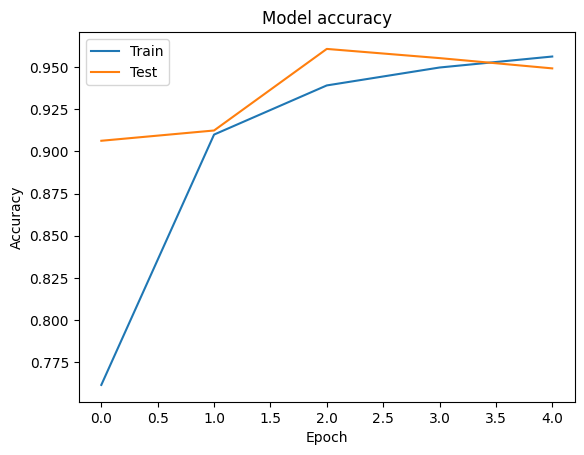

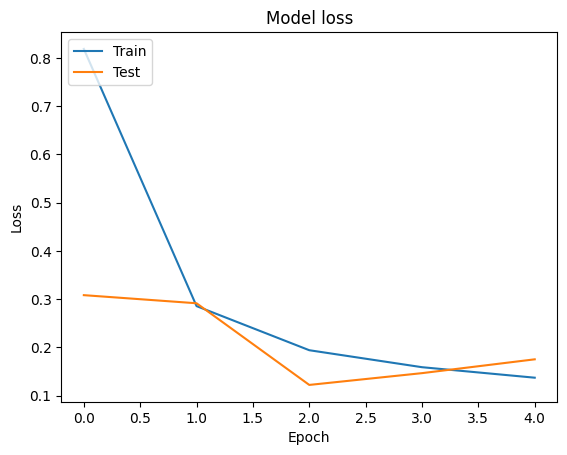

In [25]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

**Building a Predictive System**

In [26]:
# Function to Load and Preprocess the Image using Pillow
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    # Load the image
    img = Image.open(image_path)
    # Resize the image
    img = img.resize(target_size)
    # Convert the image to a numpy array
    img_array = np.array(img)
    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)
    # Scale the image values to [0, 1]
    img_array = img_array.astype('float32') / 255.
    return img_array

# Function to Predict the Class of an Image
def predict_image_class(model, image_path, class_indices):
    preprocessed_img = load_and_preprocess_image(image_path)
    predictions = model.predict(preprocessed_img)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_name = class_indices[predicted_class_index]
    return predicted_class_name

In [27]:
# Create a mapping from class indices to class names
class_indices = {v: k for k, v in train_generator.class_indices.items()}

In [28]:
class_indices

{0: 'Apple___Apple_scab',
 1: 'Apple___Black_rot',
 2: 'Apple___Cedar_apple_rust',
 3: 'Apple___healthy',
 4: 'Blueberry___healthy',
 5: 'Cherry_(including_sour)___Powdery_mildew',
 6: 'Cherry_(including_sour)___healthy',
 7: 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 8: 'Corn_(maize)___Common_rust_',
 9: 'Corn_(maize)___Northern_Leaf_Blight',
 10: 'Corn_(maize)___healthy',
 11: 'Grape___Black_rot',
 12: 'Grape___Esca_(Black_Measles)',
 13: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 14: 'Grape___healthy',
 15: 'Orange___Haunglongbing_(Citrus_greening)',
 16: 'Peach___Bacterial_spot',
 17: 'Peach___healthy',
 18: 'Pepper,_bell___Bacterial_spot',
 19: 'Pepper,_bell___healthy',
 20: 'Potato___Early_blight',
 21: 'Potato___Late_blight',
 22: 'Potato___healthy',
 23: 'Raspberry___healthy',
 24: 'Soybean___healthy',
 25: 'Squash___Powdery_mildew',
 26: 'Strawberry___Leaf_scorch',
 27: 'Strawberry___healthy',
 28: 'Tomato___Bacterial_spot',
 29: 'Tomato___Early_blight',
 30: '

In [29]:
# saving the class names as json file
json.dump(class_indices, open('class_indices.json', 'w'))

In [32]:
# Example Usage - Use an image from the dataset
import os

# Find a sample image from the dataset
sample_class = os.listdir(base_dir)[0]  # Get first class folder
sample_image_file = os.listdir(os.path.join(base_dir, sample_class))[0]  # Get first image
image_path = os.path.join(base_dir, sample_class, sample_image_file)

print(f"Using sample image: {image_path}")
print(f"Actual class: {sample_class}")

predicted_class_name = predict_image_class(model, image_path, class_indices)

# Output the result
print("Predicted Class Name:", predicted_class_name)
print("Actual Class:", sample_class)
print("Correct Prediction:", predicted_class_name == sample_class)

Using sample image: plantvillage dataset/color/Potato___healthy/43fd6ace-3712-494a-9aba-de5482d22561___RS_HL 1968.JPG
Actual class: Potato___healthy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted Class Name: Potato___healthy
Actual Class: Potato___healthy
Correct Prediction: True


**Save the model to Google drive or local**

In [33]:
model.save('drive/MyDrive/Youtube/trained_models/plant_disease_prediction_model.h5')

In [35]:
# Save the hybrid model
model.save('hybrid_vit_cnn_plant_disease_model.h5')
print("Hybrid ViT + CNN model saved successfully!")

# Also save in native Keras format (recommended)
model.save('hybrid_vit_cnn_plant_disease_model.keras')
print("Hybrid model saved in native Keras format!")

Hybrid ViT + CNN model saved successfully!
Hybrid model saved in native Keras format!
